In [1]:
!pip install pillow matplotlib opencv-python numpy

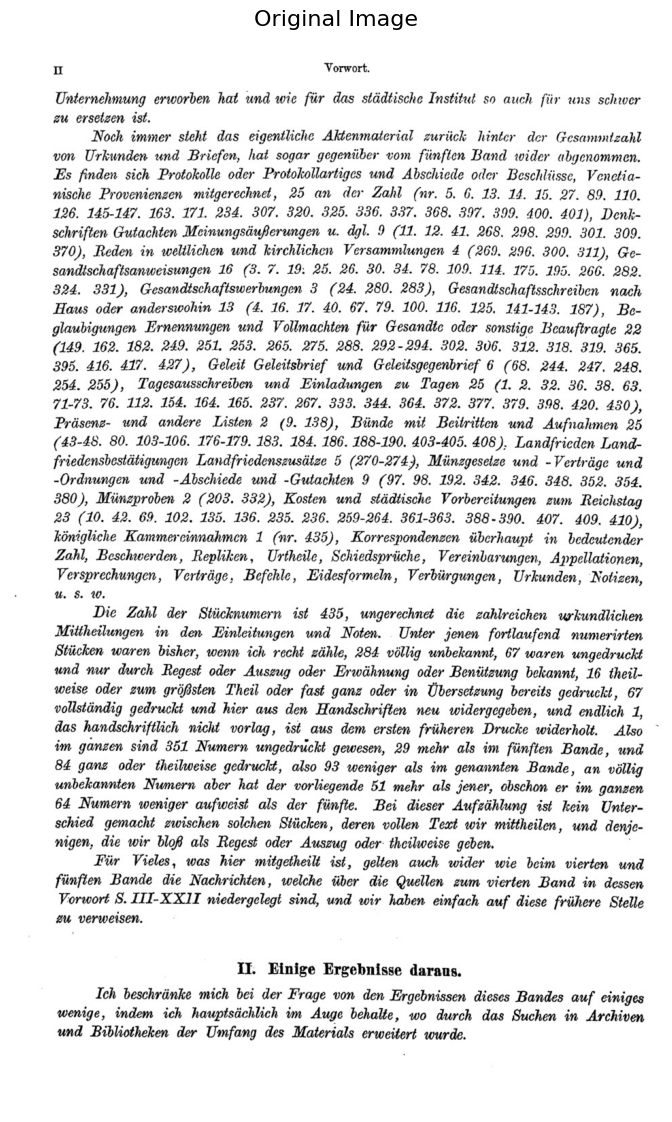

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

#Orginal Image
image_path = "../GPT_5.4/images/9.jpg"  


original_img = Image.open(image_path).convert("RGB")


plt.figure(figsize=(10, 14))
plt.imshow(original_img)
plt.title("Original Image", fontsize=16)
plt.axis("off")
plt.show()

In [13]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v1(image):
    img = np.array(image.convert("RGB"))


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #sharpen 
    kernel = np.array([
        [0, -1, 0],
        [-1, 5,-1],
        [0, -1, 0]
    ])
    sharpened = cv2.filter2D(gray, -1, kernel)


    _, binary = cv2.threshold(
        sharpened,
        180, 
        255,
        cv2.THRESH_BINARY
    )

    return Image.fromarray(binary)

In [14]:
preprocessed_img = preprocess_image_v1(original_img)

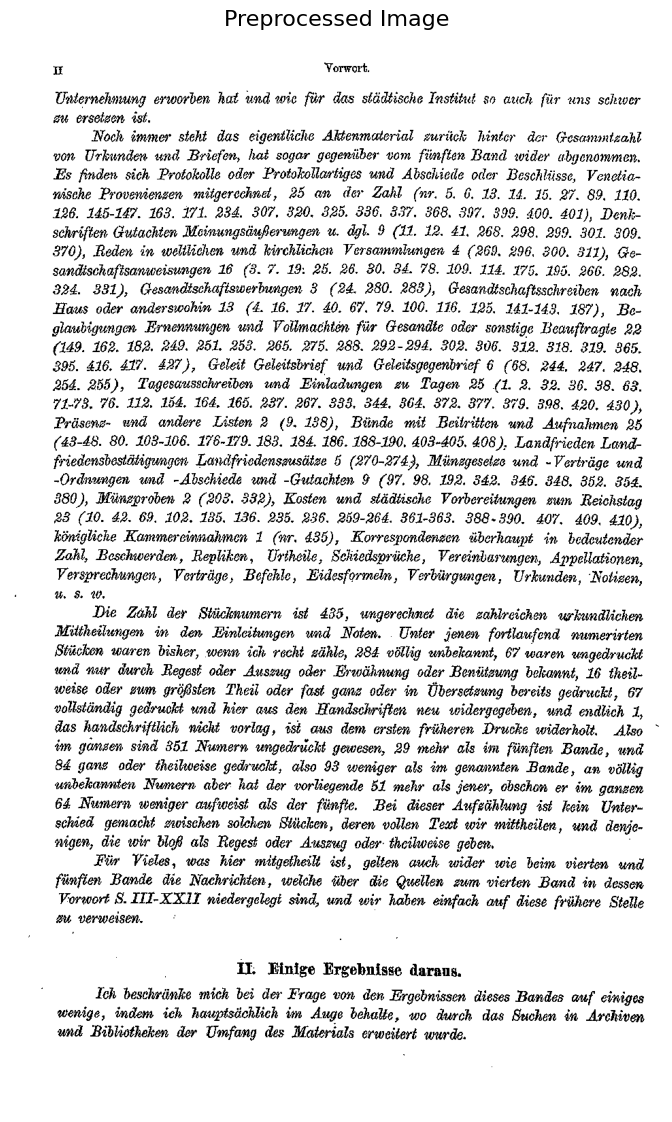

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_img, cmap="gray")
plt.title("Preprocessed Image", fontsize=16)
plt.axis("off")
plt.show()

In [16]:
output_path = "Preprocessing_test/9_preprocessed_v1.jpg"
preprocessed_img.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v1.jpg


In [17]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v2(image):
    img = np.array(image.convert("RGB"))


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


    contrast = cv2.convertScaleAbs(gray, alpha=1.15, beta=5)


    blur = cv2.GaussianBlur(contrast, (0, 0), 1.0)
    sharpened = cv2.addWeighted(contrast, 1.3, blur, -0.3, 0)

    return Image.fromarray(sharpened)

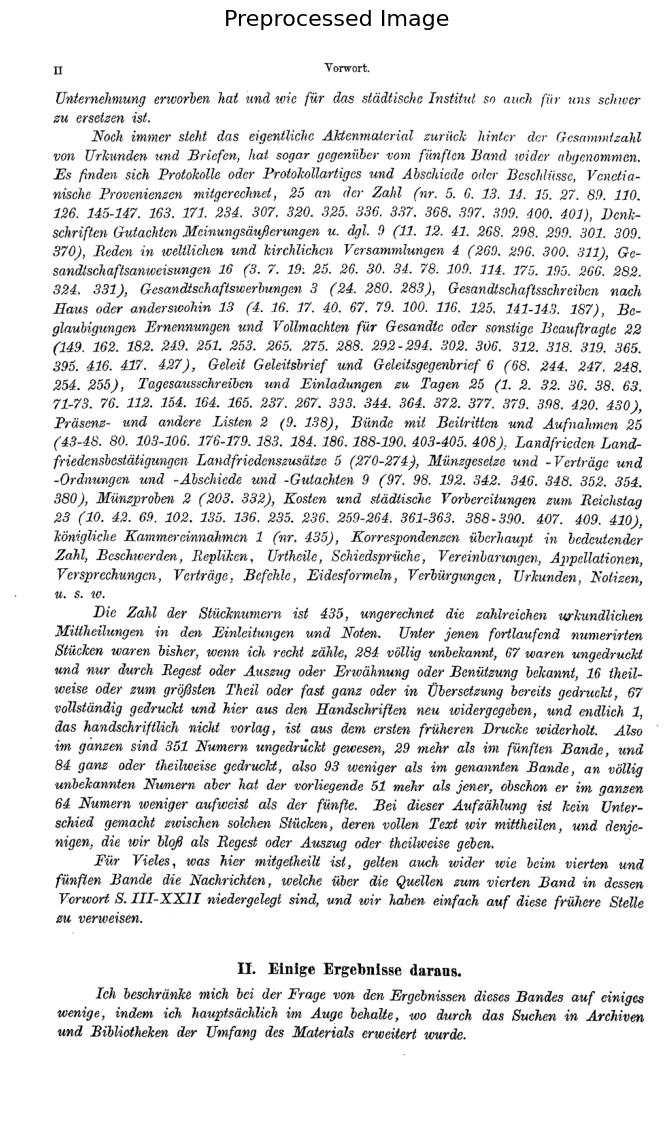

In [18]:
preprocessed_img2 = preprocess_image_v2(original_img)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_img2, cmap="gray")
plt.title("Preprocessed Image", fontsize=16)
plt.axis("off")
plt.show()

In [19]:
output_path = "Preprocessing_test/9_preprocessed_v2.jpg"
preprocessed_img2.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v2.jpg


In [20]:
# better than oroginal image - still not good.
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v3(image):
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    upscaled = cv2.resize(
        gray,
        None,
        fx=2,
        fy=2,
        interpolation=cv2.INTER_LANCZOS4
    )


    enhanced = cv2.convertScaleAbs(upscaled, alpha=1.15, beta=2)

    result = enhanced.copy()
    text_mask = result < 190
    result[text_mask] = np.clip(result[text_mask] * 0.75, 0, 255)

    blur = cv2.GaussianBlur(result, (0, 0), 0.8)
    result = cv2.addWeighted(result, 1.4, blur, -0.4, 0)

    result[result > 240] = 255

    return Image.fromarray(result)

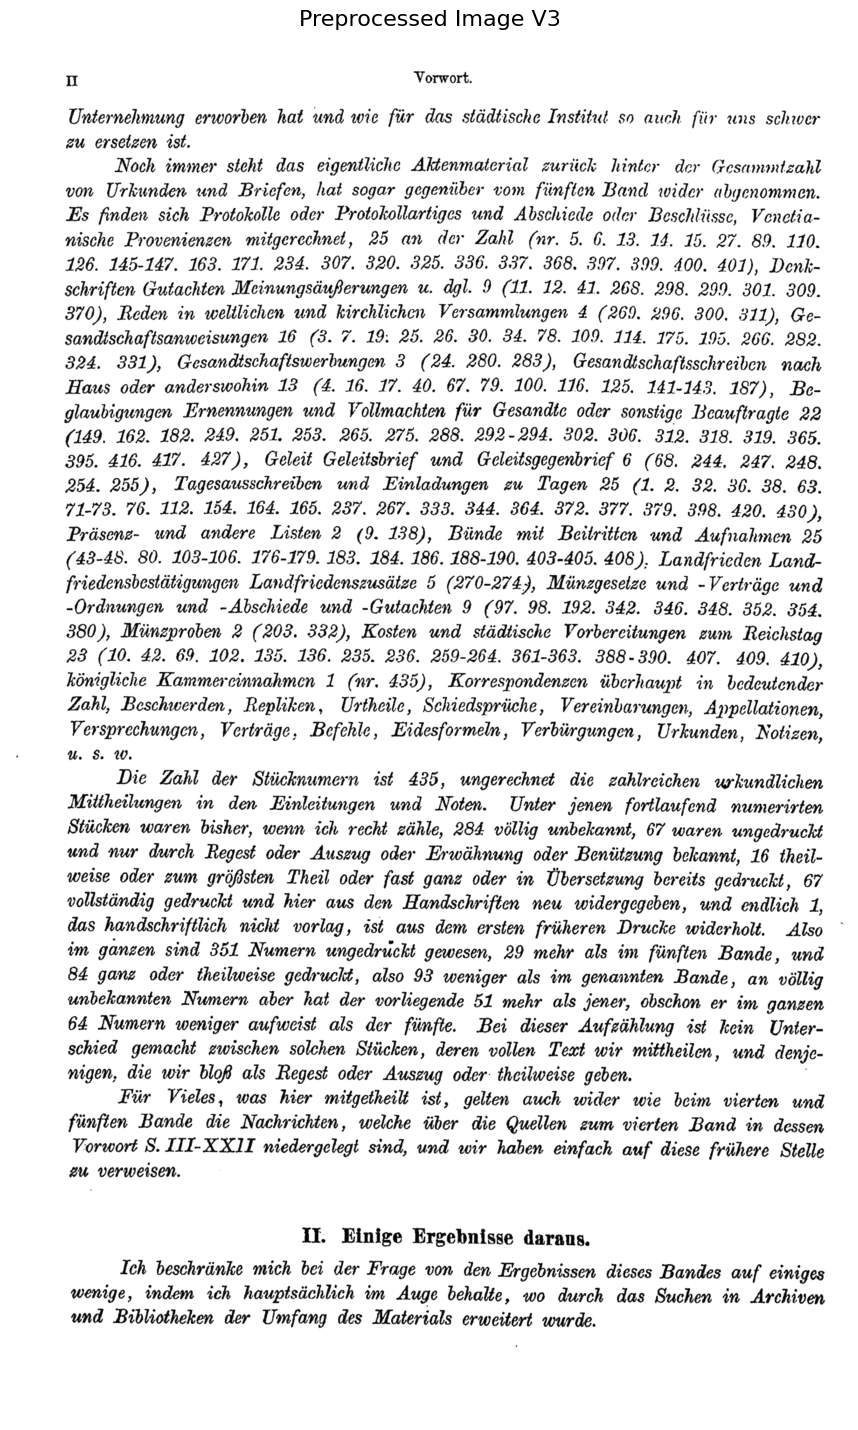

In [21]:
preprocessed_img_v3 = preprocess_image_v3(original_img)

plt.figure(figsize=(12, 18))
plt.imshow(preprocessed_img_v3, cmap="gray")
plt.title("Preprocessed Image V3", fontsize=16)
plt.axis("off")
plt.show()

In [22]:
output_path = "Preprocessing_test/9_preprocessed_v3.jpg"
preprocessed_img_v3.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v3.jpg


## Real-ESRGAN - AI Preprocessing 

In [52]:
!pip install realesrgan basicsr facexlib gfpgan

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached scikit_image-0.25.2-cp310-cp310-win_amd64.whl.metadata (14 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached imageio

In [53]:
import os
import urllib.request

model_path = "RealESRGAN_x4plus.pth"

if not os.path.exists(model_path):
    print("Downloading Real-ESRGAN model...")
    urllib.request.urlretrieve(
        "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth",
        model_path
    )
    print("Download complete.")
else:
    print("Model already exists.")

Download complete.


In [56]:
import os
import site

for site_path in site.getsitepackages():
    file_path = os.path.join(site_path, "basicsr", "data", "degradations.py")

    if os.path.exists(file_path):
        print("Found:", file_path)

        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        text = text.replace(
            "from torchvision.transforms.functional_tensor import rgb_to_grayscale",
            "from torchvision.transforms.functional import rgb_to_grayscale"
        )

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text)

        print("Fixed BasicSR compatibility issue.")

Found: C:\ProgramData\anaconda3\envs\openai-cloud\lib\site-packages\basicsr\data\degradations.py
Fixed BasicSR compatibility issue.


In [57]:
import cv2
import numpy as np
from PIL import Image
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

def preprocess_realesrgan(image):
    img = np.array(image.convert("RGB"))

    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4
    )

    upsampler = RealESRGANer(
        scale=4,
        model_path="RealESRGAN_x4plus.pth",
        model=model,
        tile=400,
        tile_pad=10,
        pre_pad=0,
        half=False
    )

    output, _ = upsampler.enhance(img, outscale=4)

    return Image.fromarray(output)

	Tile 1/12
	Tile 2/12
	Tile 3/12
	Tile 4/12
	Tile 5/12
	Tile 6/12
	Tile 7/12
	Tile 8/12
	Tile 9/12
	Tile 10/12
	Tile 11/12
	Tile 12/12


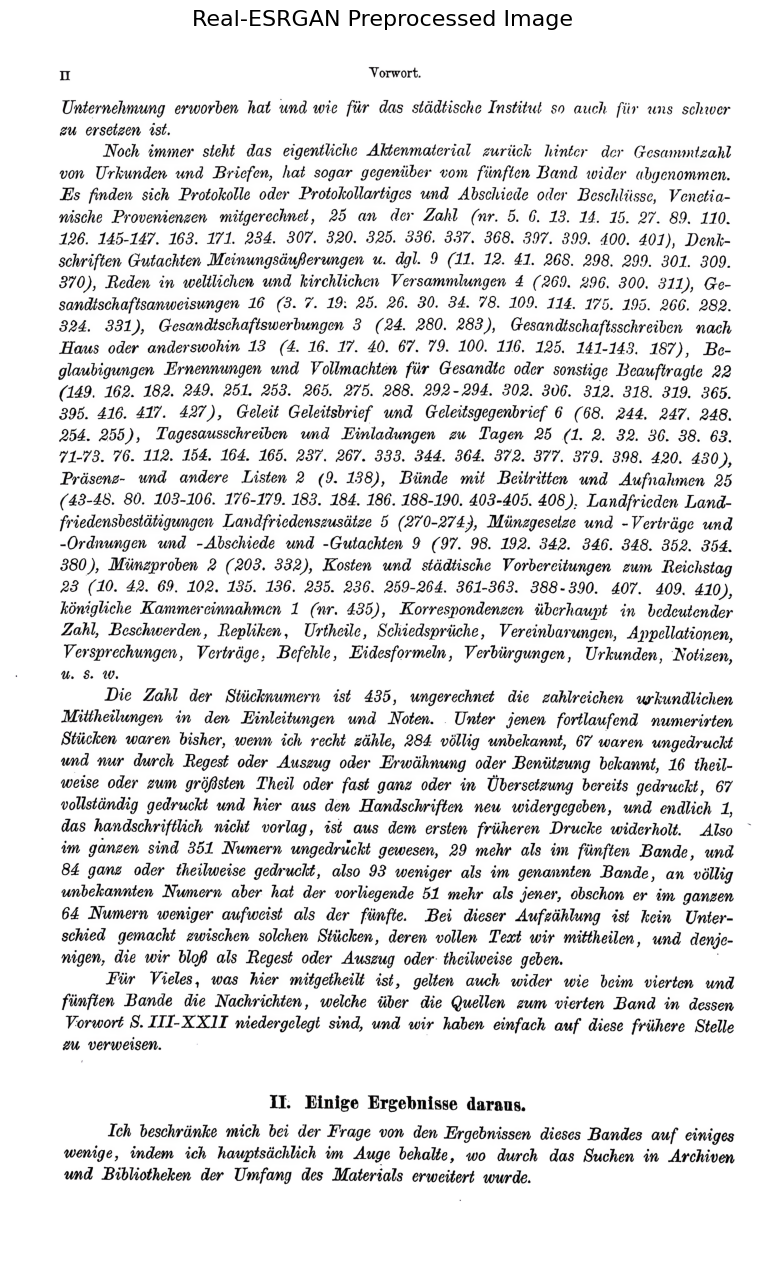

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../GPT_5.4/images/9.jpg"

original_img = Image.open(image_path).convert("RGB")

realesrgan_img = preprocess_realesrgan(original_img)

plt.figure(figsize=(12, 16))
plt.imshow(realesrgan_img)
plt.title("Real-ESRGAN Preprocessed Image", fontsize=16)
plt.axis("off")
plt.show()

In [60]:
output_path = "Preprocessing_test/9_ESRGAN_v4_ai_preprocessed.jpg"
realesrgan_img.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_ESRGAN_v4_ai_preprocessed.jpg
